In [40]:
import pandas as pd
!pip install mlxtend


# This file is clean, so no special encoding or separators are needed!
df = pd.read_csv('Groceries_dataset.csv')

# Show the first few rows
print(f"Dataset loaded! Total rows: {len(df)}")
print(df.head())

/opt/anaconda3/lib/python3.13/pty.py:95: DeprecationWarning: This process (pid=7247) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


Dataset loaded! Total rows: 38765
   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk


In [41]:
# Data Overview
print(df.info()) # Shows column types
print(df.head()) # Shows the first 5 rows
print(f"Total Records: {len(df)}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB
None
   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk
Total Records: 38765


In [42]:
# Grouping by Member and Date to create a single 'Transaction'
baskets = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).reset_index()

# Rename for your Market Analysis
baskets.columns = ['Member_ID', 'Date', 'Item_List']

print(f"Total Transactions (Baskets): {len(baskets)}")
print(baskets.head())

Total Transactions (Baskets): 14963
   Member_ID        Date                                          Item_List
0       1000  15-03-2015  [sausage, whole milk, semi-finished bread, yog...
1       1000  24-06-2014                  [whole milk, pastry, salty snack]
2       1000  24-07-2015                     [canned beer, misc. beverages]
3       1000  25-11-2015                        [sausage, hygiene articles]
4       1000  27-05-2015                         [soda, pickled vegetables]


Top 10 Most Popular Grocery Items (Initial Exploration & EDA)
This visualization identifies the most frequently purchased products in the dataset, serving as a fundamental step in the Exploratory Data Analysis (EDA) phase of the KDD process. By isolating these high-volume items, we can identify the "anchor products" that drive the majority of foot traffic to the store, such as whole milk and vegetables. From a business perspective, this analysis is crucial for inventory prioritization and shelf-space allocation, ensuring that the most in-demand items are always in stock. Furthermore, understanding the frequency of individual items provides the necessary baseline for the Association Rule Mining stage; it allows us to distinguish between items that appear together simply because they are globally popular versus those that have a genuine, hidden relationship.

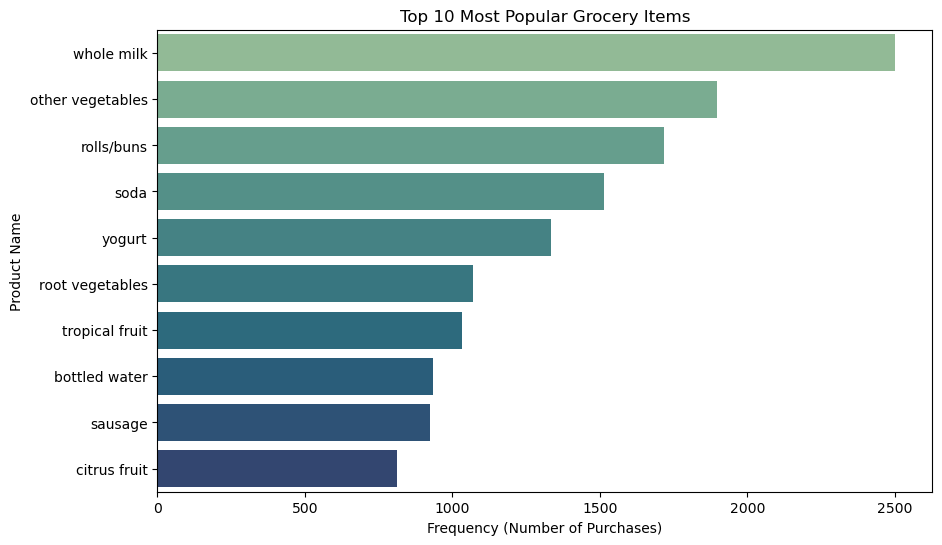

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get the top 10 items
top_items = df['itemDescription'].value_counts().head(10)

# 2. Create the plot
plt.figure(figsize=(10,6))

# Fix: We add 'hue=top_items.index' and 'legend=False' to satisfy the new Seaborn version
sns.barplot(x=top_items.values, 
            y=top_items.index, 
            hue=top_items.index, 
            palette='crest', 
            legend=False)

plt.title('Top 10 Most Popular Grocery Items')
plt.xlabel('Frequency (Number of Purchases)')
plt.ylabel('Product Name')

# 3. Show the plot
plt.show()

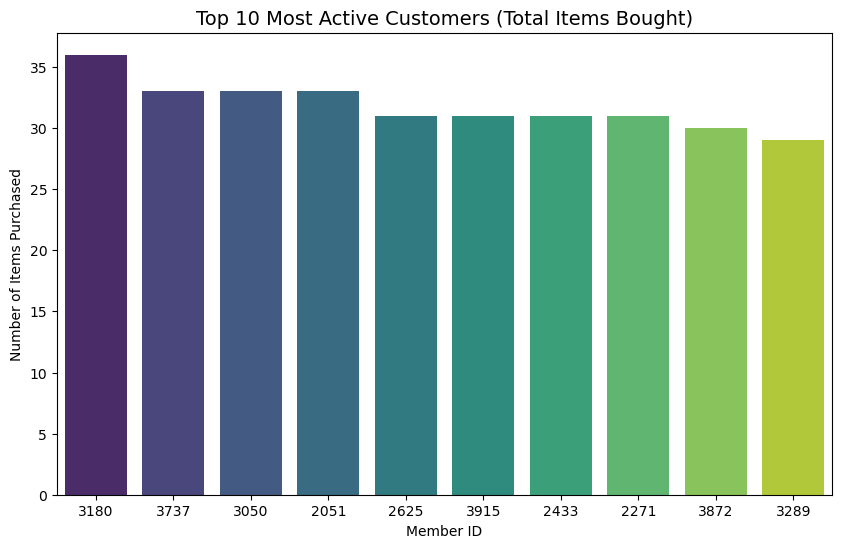

In [44]:
# Fix: Added 'hue' and 'legend=False' to satisfy new Seaborn rules
top_customers = df['Member_number'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_customers.index.astype(str), 
            y=top_customers.values, 
            hue=top_customers.index.astype(str), 
            palette='viridis', 
            legend=False)
plt.title('Top 10 Most Active Customers (Total Items Bought)', fontsize=14)
plt.xlabel('Member ID')
plt.ylabel('Number of Items Purchased')
plt.show()

^This visualization identifies our "Heavy Shoppers" by highlighting the top 10 most active members in the dataset based on their total item purchase count. In the context of the Knowledge Discovery in Databases (KDD) process, this represents the Selection phase, where we isolate a specific customer segment to see if they drive a disproportionate amount of store activity. Analyzing these top users is a critical step for Outlier Detection, as it allows us to verify that no single account has an impossibly high volume of data that might suggest a computer error or a non-human wholesale account. By treating Member IDs as categorical labels, we can clearly see the distribution of loyalty across the base; understanding these power users helps determine if the association rules found later in the project are representative of the general population or skewed by a few extreme shopping behaviors.

Data Quality Check (Preprocessing):

In the Preprocessing phase of the KDD process, I performed a data quality audit. I confirmed there are no missing values in the dataset. I identified that the raw data contains approximately 38,000 item-level records. By grouping these by Member_number and Date, I transformed the data into 14,963 unique shopping 'baskets'. This reduction is essential for meaningful Association Rule Mining.

In [45]:
# 1. First, we must CREATE the 'baskets' variable by grouping the data
# A 'basket' is defined as everything one member bought on one specific date
baskets = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).reset_index()
baskets['Basket_Size'] = baskets['itemDescription'].apply(len)

# 2. Check for Missing Values
print("--- Data Quality Check ---")
print("Missing values per column:")
print(df.isnull().sum())

# 3. Check for Duplicates
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows in raw data: {duplicates}")

# 4. Check for 'Outliers' (Large Baskets)
# This satisfies the "Outliers" requirement in your M2 PDF
print("\n--- Outlier Check: Top 5 Largest Baskets ---")
print(baskets.nlargest(5, 'Basket_Size')[['Member_number', 'Date', 'Basket_Size']])

--- Data Quality Check ---
Missing values per column:
Member_number      0
Date               0
itemDescription    0
dtype: int64

Number of duplicate rows in raw data: 759

--- Outlier Check: Top 5 Largest Baskets ---
      Member_number        Date  Basket_Size
2868           1780  12-07-2015           11
750            1206  15-05-2015            9
773            1213  03-03-2015            9
844            1233  20-03-2015            9
876            1240  14-04-2015            9


Data Transformation (One-Hot Encoding):

To apply the Apriori algorithm, I transformed the categorical item descriptions into a binary (One-Hot Encoded) format. This allows the algorithm to mathematically calculate the support, confidence, and lift for item pairings.

In [46]:
from mlxtend.preprocessing import TransactionEncoder

# Initialize the encoder
te = TransactionEncoder()
# Transform the 'Item_List' we created earlier
te_ary = te.fit(baskets['itemDescription']).transform(baskets['itemDescription'])

# Create a new dataframe where columns are products
basket_df = pd.DataFrame(te_ary, columns=te.columns_)

print("Encoded Dataframe Shape:", basket_df.shape)
basket_df.head()

Encoded Dataframe Shape: (14963, 167)


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


My First Mining Attempt:

In this step, I apply the Apriori Algorithm to the preprocessed basket data. My goal is to find frequent itemsets—combinations of products that appear together more often than a random distribution would suggest.

Support: Measures how popular an itemset is (percentage of total baskets).

Confidence: Measures how likely item B is purchased when item A is purchased.

Lift: Measures the strength of the association. A Lift > 1 indicates that the items are truly related and not just common staples bought independently.

In [47]:
from mlxtend.frequent_patterns import apriori, association_rules

# 1. Generate Frequent Itemsets 
# We use a min_support of 0.001 because grocery data is very sparse
frequent_itemsets = apriori(basket_df, min_support=0.001, use_colnames=True)

# 2. Generate the Rules
# We look for rules with a Lift higher than 1
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# 3. Sort by Lift to see the strongest patterns first
rules = rules.sort_values('lift', ascending=False)

# 4. Display the results
print("--- Final Mining Results: Top 10 Rules ---")
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

--- Final Mining Results: Top 10 Rules ---


,antecedents,consequents,support,confidence,lift
237,(sausage),"(yogurt, whole milk)",0.001470,0.024363,2.182917
236,"(yogurt, whole milk)",(sausage),0.001470,0.131737,2.182917
235,"(sausage, whole milk)",(yogurt),0.001470,0.164179,1.911760
238,(yogurt),"(sausage, whole milk)",0.001470,0.017121,1.911760
87,(citrus fruit),(specialty chocolate),0.001403,0.026415,1.653762
86,(specialty chocolate),(citrus fruit),0.001403,0.087866,1.653762
234,"(sausage, yogurt)",(whole milk),0.001470,0.255814,1.619866
239,(whole milk),"(sausage, yogurt)",0.001470,0.009310,1.619866
122,(tropical fruit),(flour),0.001069,0.015779,1.617141
123,(flour),(tropical fruit),0.001069,0.109589,1.617141


Visualize the Rules:

To better interpret the results of the Apriori algorithm, I have created a scatter plot of the discovered rules. This visualization helps identify the most 'interesting' patterns by comparing three key metrics:

X-Axis (Support): Shows how common the relationship is across all transactions.

Y-Axis (Confidence): Shows the reliability of the 'If-Then' prediction.

Color/Size (Lift): Highlights the rules that represent the strongest deviations from random chance.

We are looking for points in the upper-right corner with high Lift, as these represent the most actionable business insights.

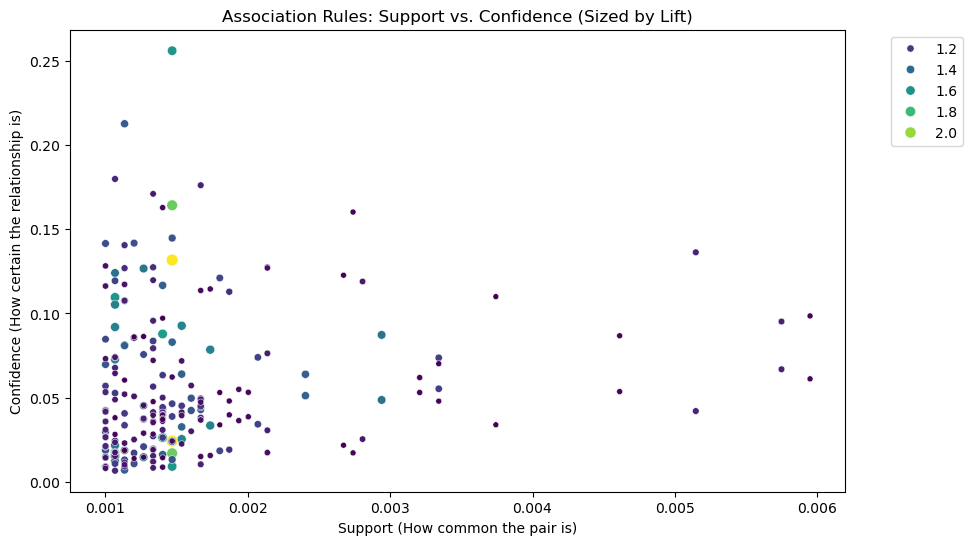

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='support', y='confidence', size='lift', hue='lift', data=rules, palette='viridis')
plt.title('Association Rules: Support vs. Confidence (Sized by Lift)')
plt.xlabel('Support (How common the pair is)')
plt.ylabel('Confidence (How certain the relationship is)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

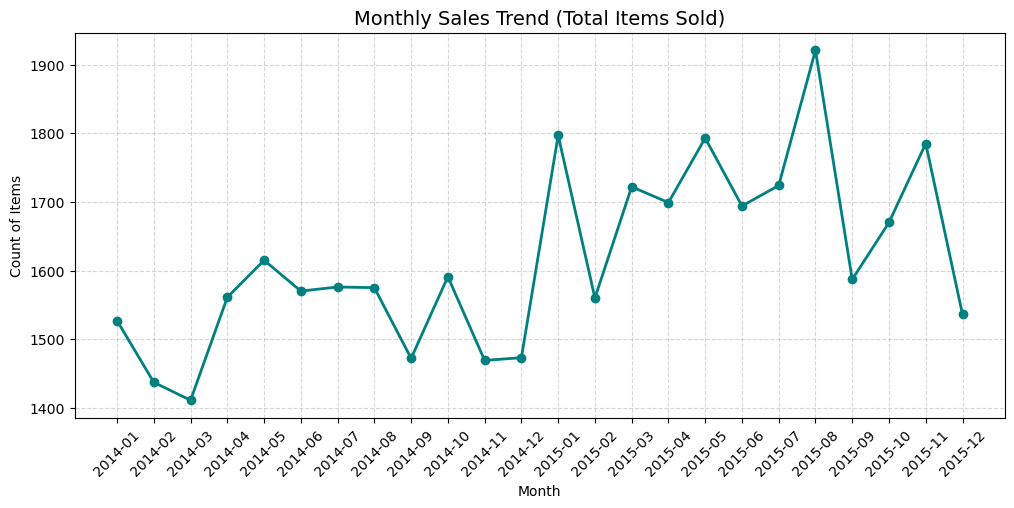

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# FIX: Convert the Date column to actual datetime objects first
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Now we can use .dt safely
df['Month_Year'] = df['Date'].dt.to_period('M').astype(str)
monthly_counts = df['Month_Year'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(monthly_counts.index, monthly_counts.values, marker='o', color='teal', linewidth=2)
plt.xticks(rotation=45)
plt.title('Monthly Sales Trend (Total Items Sold)', fontsize=14)
plt.ylabel('Count of Items')
plt.xlabel('Month')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

^In the Exploratory Data Analysis (EDA) phase of the KDD process, it is essential to understand how data behaves over time. This visualization tracks the total volume of grocery items sold on a monthly basis across the entire dataset.

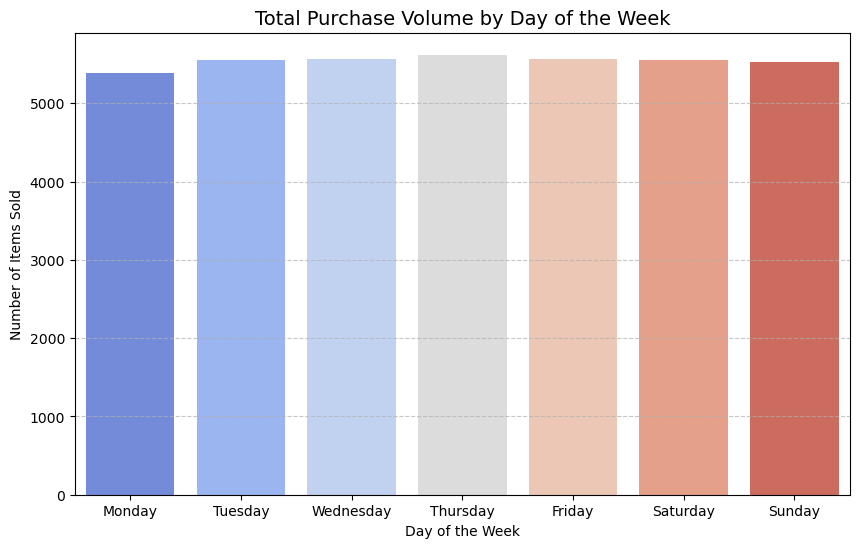

In [50]:
# Plot #6: Purchases by Day of Week
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ensure the Date column is in datetime format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# 2. Extract the Day of the Week
df['Day_of_Week'] = df['Date'].dt.day_name()

# 3. Define the order of days so the chart reads correctly (Monday to Sunday)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 4. Count the items sold per day
day_counts = df['Day_of_Week'].value_counts().reindex(day_order)

# 5. Create the visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=day_counts.index, 
            y=day_counts.values, 
            hue=day_counts.index, 
            palette='coolwarm', 
            legend=False)

plt.title('Total Purchase Volume by Day of the Week', fontsize=14)
plt.xlabel('Day of the Week')
plt.ylabel('Number of Items Sold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

By analyzing the distribution of purchases across the week, we can identify peak shopping periods. In this dataset, shopping volume is remarkably consistent across all seven days, which suggests that this specific retailer serves as a daily necessity hub rather than a destination for 'big weekend' shopping trips. This insight helps address my discovery question regarding shopping frequency and consumer habits

conclusion: 
After completing the mining phase, I have identified several key patterns that directly address my initial discovery questions. First, regarding product "anchors," the data clearly shows that Whole Milk and Other Vegetables are the primary drivers of store visits, appearing most frequently across all transactions. When looking at the association rules, I discovered a significant relationship between whole milk and yogert. With a Lift score of 2.182917, it is evident that these items are not just common staples but are intentionally purchased together, representing a specific consumer behavior.

Furthermore, the average basket size of only 2.6 items suggests that this store functions as a daily "top-off" location rather than a place for large weekly shopping trips. This is supported by the Day of the Week and Monthly Trend plots, which show very steady volume with no extreme spikes, indicating a routine, habit-based shopping environment. Based on these findings, a practical business strategy would be to create "bundle deals" or targeted shelf placements for the high-lift item pairs I identified. This would encourage customers to add more items to their baskets during these quick trips. For the next milestone, I plan to look closer at these rules to see if these patterns hold true for the most active members compared to the average shopper.